# Predict diabetes subtype classification
Analysis of pre-COVID19 UAB data by diabetes subtype classification showed racial differences in cluster distribution. Map cluster assignments from pre-COVID19 data to post-COVID19 data.

**Objective:** Assign clusters using generated random forest model to post-COVID19 data.

# Environment setup
Import required modules.

In [1]:
import numpy as np
import pandas as pd

import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

Load pre-trained random forest model to assign clusters.

In [2]:
rf_path = "/data/user/brianlu/projects/precision_diabetes/cluster_prediction/exports/models/full_linear_rf_model.joblib"

rf = joblib.load(rf_path)

Define function to calculate HOMA1 estimates.

In [3]:
# insert homa1
def insert_homa1(df):
    
    df["homa1_cpeptide_b"] = (20 * 6 * df["homa_cpeptide_cpeptide"])/(df["homa_cpeptide_glucose"]-3.5)
    df["homa1_cpeptide_ir"] = (df["homa_cpeptide_glucose"] * 6 * df["homa_cpeptide_cpeptide"]) / 22.5

    return df


Set up label encoder to convert numbered clusters to named clusters.

In [4]:
# multiple classes to predict, transform into labels
le = LabelEncoder()
le.fit(np.array(["SAID", "SIDD", "SIRD", "MOD", "MARD"]))
le.classes_ = np.array(["SAID", "SIDD", "SIRD", "MOD", "MARD"])

# Data cleaning
Load post-COVID19 data.

In [5]:
post_covid_data_path = "../exports/UAB/raw/merged.csv"
post_covid = pd.read_csv(post_covid_data_path)

post_covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51858 entries, 0 to 51857
Columns: 266 entries, DE_ID to u_ketone_diabetes_days
dtypes: float64(104), int64(13), object(149)
memory usage: 105.2+ MB


In [6]:
pd.pivot_table(post_covid[["diabetes_type", "diabetes_encounter_type_class"]], 
                                      columns = ["diabetes_type"], 
                                      index=["diabetes_encounter_type_class"], 
                                      aggfunc=len, 
                                      fill_value = 0)

diabetes_type,Secondary,Type 1,Type 2
diabetes_encounter_type_class,,,
Emergency,8,299,10026
Inpatient,95,499,16967
Observation,0,11,201
Outpatient,63,809,22808
Preadmit,0,0,1
Recurring,0,3,11


Calculate HOMA1 estimates and define features for prediction.

In [7]:
post_covid = insert_homa1(post_covid)
predictors = ["gad", "a1c", "bmi", "diabetes_age", "homa1_cpeptide_b", "homa1_cpeptide_ir"]

Removed records with incomplete data.

In [8]:
# remove data with NA
data = post_covid.dropna(subset = predictors).copy()

In [9]:
pd.pivot_table(data[["diabetes_type", "diabetes_encounter_type_class"]], 
                                      columns = ["diabetes_type"], 
                                      index=["diabetes_encounter_type_class"], 
                                      aggfunc=len, 
                                      fill_value = 0)

diabetes_type,Secondary,Type 1,Type 2
diabetes_encounter_type_class,,,
Emergency,0,1,36
Inpatient,2,14,98
Outpatient,1,5,161


Filter records to outpatients only.

In [10]:
outpatient = data[data["diabetes_encounter_type_class"] == "Outpatient"]

print(f"Number of outpatients: {outpatient.shape[0]}")

Number of outpatients: 167


Patients under 18 at the time of diabetes diagnoses were removed similar to [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2).

In [11]:
outpatient = outpatient[outpatient["diabetes_age"] >= 18]

print(f"Number of outpatients: {outpatient.shape[0]}")

Number of outpatients: 166


Remove outlier from patient groups. Outliers were defined as values greater than 5 standard deviations from the mean same as used by [Ahlqvist et al.](https://doi.org/10.1016/s2213-8587(18)30051-2)

Defined function to remove outliers based on number of standard deviations from mean. 

In [12]:
# remove outliers by z score
def remove_outlier(df, feature, distance):
    upper = []
    lower = []
    
    # find upper and lower bounds that defines an outlier
    for f in feature:
        
        # FutureWarning: Calling float on a single element Series is deprecated 
        # and will raise a TypeError in the future. 
        # Use float(ser.iloc[0]) instead
        # upper.append(float(df[[f]].mean() + distance * df[[f]].std()))
        # lower.append(float(df[[f]].mean() - distance * df[[f]].std()))
        
        upper.append((df[[f]].mean() + distance * df[[f]].std()).iloc[0])
        lower.append((df[[f]].mean() - distance * df[[f]].std()).iloc[0])
        
    # subset df to only values within the outlier boundaries
    for i in range(len(upper)):
        df = df[(df[feature[i]] < upper[i]) & (df[feature[i]] > lower[i])]
    return df

In [13]:
# define features from which to remove outliers
features_to_clean = ["diabetes_age", "a1c", "bmi", "homa_cpeptide_b", "homa_cpeptide_ir"]

# remove outliers outpatient data and print number of rows removed
outpatient_cleaned = remove_outlier(outpatient, features_to_clean, 5)
rows_removed = outpatient.shape[0] - outpatient_cleaned.shape[0]
print(f"{rows_removed} outpatients were removed as outliers.")

print(f"Number of outpatients: {outpatient_cleaned.shape[0]}")

1 outpatients were removed as outliers.
Number of outpatients: 165


Check that feature values look reasonable.

In [14]:
outpatient_cleaned[predictors].describe()

,gad,a1c,bmi,diabetes_age,homa1_cpeptide_b,homa1_cpeptide_ir
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,0.060606,8.646667,32.915152,48.164184,42.729727,3.558204
std,0.239333,2.480228,7.148602,15.012554,39.979765,2.838568
min,0.000000,4.400000,19.000000,18.375342,1.318872,0.346790
25%,0.000000,6.700000,29.000000,36.498630,15.251069,1.601808
50%,0.000000,8.000000,32.000000,49.115068,29.628186,2.801497
75%,0.000000,10.400000,38.000000,59.627397,54.771029,4.824408
max,1.000000,15.100000,60.000000,89.416438,194.948167,15.907916


# Cluster assignment
Use model to assign clusters.

In [15]:
# assign cluster based on trained model
mapped_clusters = rf.predict(outpatient_cleaned[predictors])

# convert encoded labels back to cluster names
mapped_clusters = le.inverse_transform(mapped_clusters)

# insert back into data
outpatient_cleaned["mapped_cluster"] = mapped_clusters

Clusters have similar feature distribution as [Lu et al.](https://doi.org/10.1210/clinem/dgae516) except SIRD doesn't have the highest HOMA-IR. Difference may be due to the lower number of patients resulting in skewed feature distrubutions. 

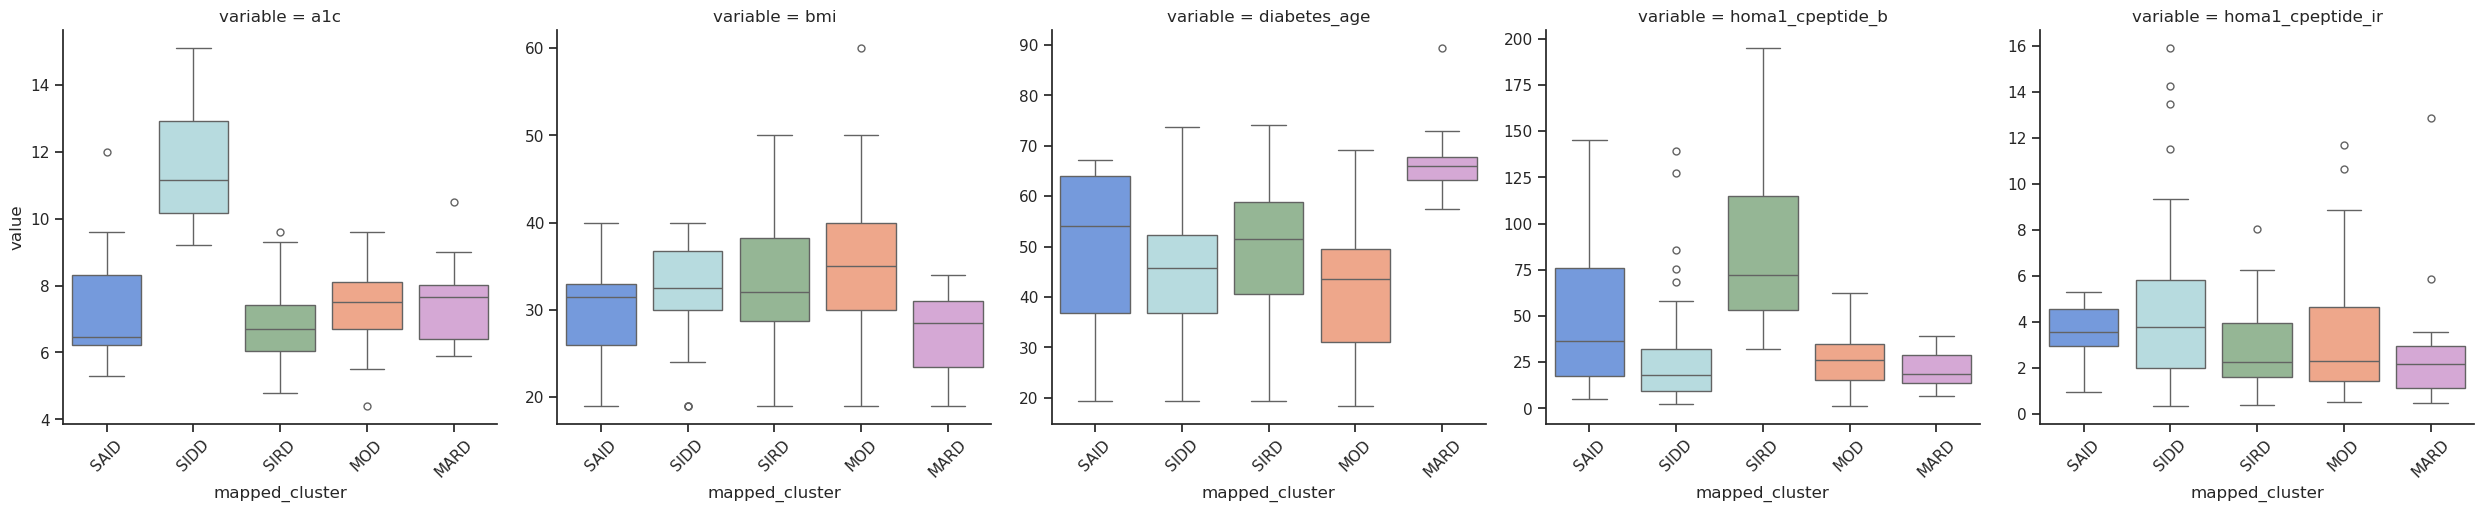

In [16]:
import seaborn as sns
sns.set(font_scale = 1, style = "ticks")
# convert data to long form for graphing[
data_long = outpatient_cleaned.melt(id_vars = "mapped_cluster", 
                                                   value_vars = ["a1c", "bmi", "diabetes_age", 
                                                                 "homa1_cpeptide_b", "homa1_cpeptide_ir"])

# plot features by cluster
color = ["cornflowerblue", "powderblue", "darkseagreen", "lightsalmon", "plum"]
order = ["SAID", "SIDD", "SIRD", "MOD", "MARD"]

sns.catplot(data = data_long, 
            x = "mapped_cluster", 
            y = "value", 
            col = "variable", 
            col_wrap = 5, 
            kind = "box", 
            sharey = False,
            order = order,
            hue = "mapped_cluster",
            palette = {key: value for key, value in zip(order, color)}
           ).set_xticklabels(labels = order, rotation = 45);

# Export results

Create export directory.

In [17]:
from watermark import watermark
import os

# define export directory
export_dir_path = "../exports/UAB/"

# create export directory if folder doesn't exist
if not os.path.isdir(export_dir_path):
    os.mkdir(export_dir_path)

Export results.

In [18]:
outpatient_cleaned.to_csv(export_dir_path + "uab_mapped_outpatient.csv", index = False)

In [19]:
print(watermark())

Last updated: 2025-06-30T10:38:30.710406-05:00

Python implementation: CPython
Python version       : 3.12.6
IPython version      : 8.27.0

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 3.10.0-1160.24.1.el7.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 48
Architecture: 64bit

